# ADV bulk-statistics QC

Look for strange points in the bulk wave statistics of every Vector.

1. Split each sensor's QC'd pressure record (`data/processed/qc/{S}_QC.nc`) into 512 s segments.
2. Pressure → surface elevation η with the granolas transfer function (`depth_correct_eta`, cosh(kh)).
3. Hs = 4√m0 from the Welch spectrum of η (`eta_psd_welch` + `bulk_stats_from_psd`).
4. Plot the 512 s Hs time series, one figure per sensor, in 3-week panels with a line every 3 h.

Kernel: **Python (analysiz)** (has granolas).

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from granolas import depth_correct_eta, eta_psd_welch, bulk_stats_from_psd

# ---- paths ----
QC_DIR  = '../data/processed/qc'    # {S}_QC.nc live here
FIG_DIR = '../figs/qc'

# ---- sensors ----
SENSORS = ['VA10', 'VB5', 'VC5', 'VC10', 'VD5', 'VD10', 'VE4', 'VE7', 'VE10']

# ---- segmenting ----
SEG      = 512      # segment length [s]
FS       = 2.0      # Vector sample rate [Hz]
MIN_FRAC = 0.99     # keep a segment only if it has >= 99 % of its samples

# ---- physics ----
RHO = 1025.0        # seawater density [kg/m^3]
G   = 9.81          # gravity [m/s^2]

# ---- spectra / Hs ----
NPERSEG    = 256            # Welch window = 128 s -> 7 windows (50 % overlap) per 512 s segment
FMIN, FMAX = 0.04, 0.25     # Hs band [Hz] (same band as Hs_SS in the QC files)
F_CUT      = FMAX           # transfer function zeroes energy above this [Hz]

# ---- plotting ----
PANEL = pd.Timedelta(days=21)   # each panel spans 3 weeks
VLINE = '3h'                    # vertical line spacing

## 512 s segments → η → Hs

In [2]:
def hs_512(p, z_p):
    """Hs and depth for every 512 s segment of a pressure record.

    p   : pd.Series of pressure [dbar] on a DatetimeIndex
    z_p : height of the pressure port above the bed [m]
    """
    n_full = SEG * FS                                   # samples in a full segment (1024)
    rows = []
    for t0, seg in p.groupby(pd.Grouper(freq=f'{SEG}s')):
        seg = seg.dropna()
        if len(seg) < MIN_FRAC * n_full:                # partial / gappy segment -> skip
            continue
        p_m   = seg.to_numpy() * 1e4 / (RHO * G)        # dbar -> Pa -> m of water (hydrostatic)
        h     = p_m.mean() + z_p                        # water depth = mean head + port height
        eta_h = p_m - p_m.mean()                        # hydrostatic surface elevation (demeaned)
        eta   = depth_correct_eta(eta_h, h, fs=FS, f_cutoff=F_CUT)   # cosh(kh) transfer function
        f, S  = eta_psd_welch(eta, fs=FS, nperseg=NPERSEG)            # PSD of eta [m^2/Hz]
        Hs    = bulk_stats_from_psd(S, f, fmin=FMIN, fmax=FMAX)['Hs'] # 4 sqrt(m0) over the band
        rows.append({'time': t0 + pd.Timedelta(seconds=SEG / 2),     # stamp at segment center
                     'Hs': Hs, 'h': h})
    return pd.DataFrame(rows).set_index('time')

In [3]:
# Batch every sensor. Only the pressure channel is loaded (files are ~340 MB each).
hs = {}
for S in SENSORS:
    ds  = xr.open_dataset(f'{QC_DIR}/{S}_QC.nc')
    p   = ds['p'].to_series()                     # pressure [dbar], atmosphere removed
    z_p = ds.attrs['zt_z_p_m']                    # pressure-port height above bed [m]
    hs[S] = hs_512(p, z_p)
    ds.close()
    print(f"{S:5s}  {len(hs[S]):5d} segments   Hs {hs[S].Hs.min():.2f}-{hs[S].Hs.max():.2f} m")

# Save one small table so later runs can skip the big files.
out = pd.concat(hs, names=['sensor']).reset_index()
out.to_csv(f'{QC_DIR}/adv_Hs512.csv', index=False)

VA10    9935 segments   Hs 0.50-6.05 m


VB5     9769 segments   Hs 0.51-3.47 m


VC5     9918 segments   Hs 0.44-2.48 m


VC10    9779 segments   Hs 0.46-4.76 m


VD5     9953 segments   Hs 0.39-2.90 m


VD10    9782 segments   Hs 0.35-5.18 m


VE4     9965 segments   Hs 0.39-2.34 m


VE7     9976 segments   Hs 0.37-2.70 m


VE10    9772 segments   Hs 0.34-4.96 m


In [4]:
# Sanity check: hourly mean of the 512 s Hs should match Hs_SS from adv_QC (ratio ~ 1).
ds   = xr.open_dataset(f'{QC_DIR}/VC5_QC.nc')
hs_h = hs['VC5'].Hs.resample('1h').mean()
ref  = ds['Hs_SS'].to_series()
ds.close()
print('VC5 median Hs512 / Hs_SS =', round(float((hs_h / ref).median()), 3))

VC5 median Hs512 / Hs_SS = 0.981


## Plot: one figure per sensor, 3-week panels, line every 3 h

In [5]:
def plot_hs(df, name):
    """Hs time series split into 3-week panels, grey line every 3 h."""
    start   = df.index[0].floor('D')                         # first panel starts at midnight
    n_panel = int(np.ceil((df.index[-1] - start) / PANEL))   # number of 3-week panels
    fig, axs = plt.subplots(n_panel, 1, figsize=(14, 2.6 * n_panel), sharey=True, squeeze=False)

    for i, ax in enumerate(axs[:, 0]):
        t0, t1 = start + i * PANEL, start + (i + 1) * PANEL   # this panel's time window
        for t in pd.date_range(t0, t1, freq=VLINE):          # vertical line every 3 h
            ax.axvline(t, lw=0.3, color='0.85', zorder=0)
        d = df[t0:t1]
        ax.plot(d.index, d.Hs, '.', ms=2, color='k')         # 512 s Hs points
        ax.set_xlim(t0, t1)
        ax.set_ylabel('Hs (m)')

    axs[0, 0].set_title(f'{name}: 512 s Hs ({FMIN}-{FMAX} Hz)')
    fig.tight_layout()
    fig.savefig(f'{FIG_DIR}/ADV_Hs512_{name}.png', dpi=150)
    plt.show()

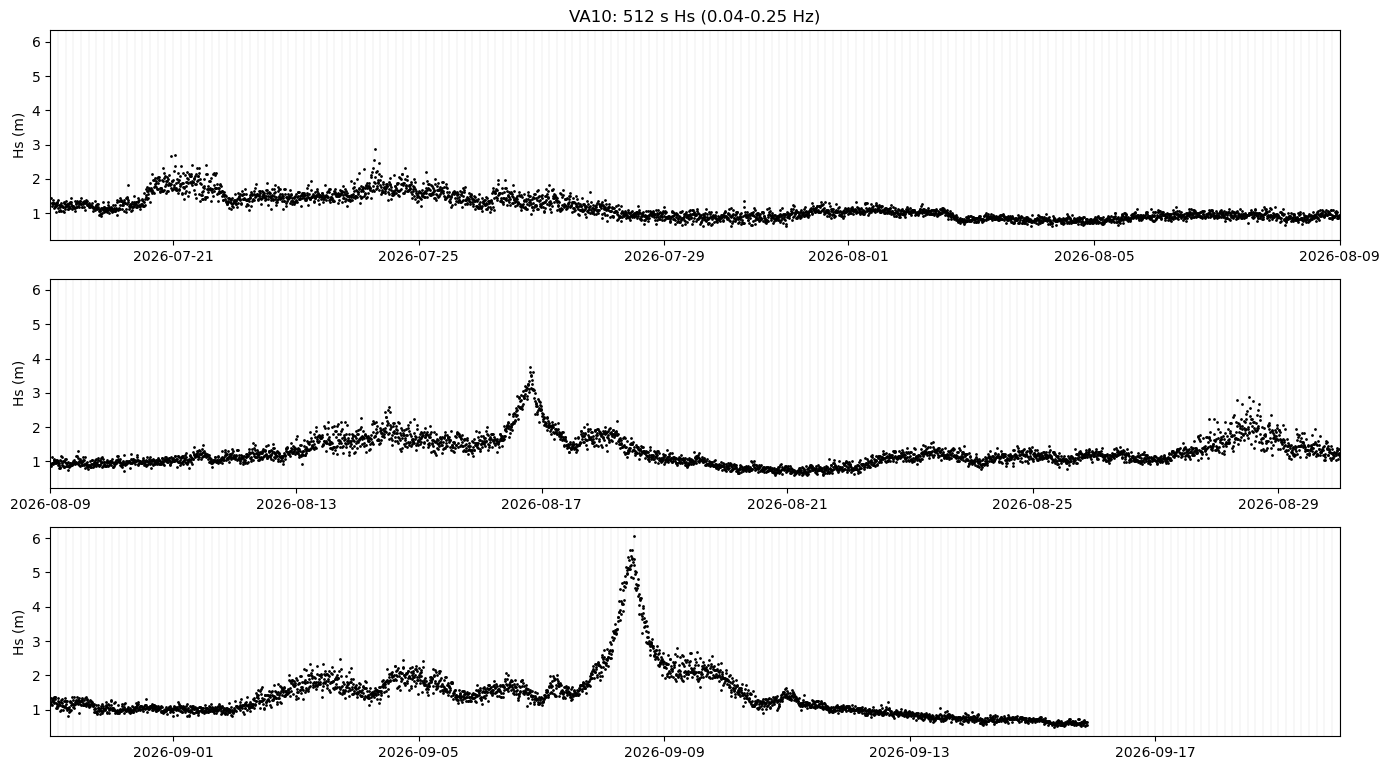

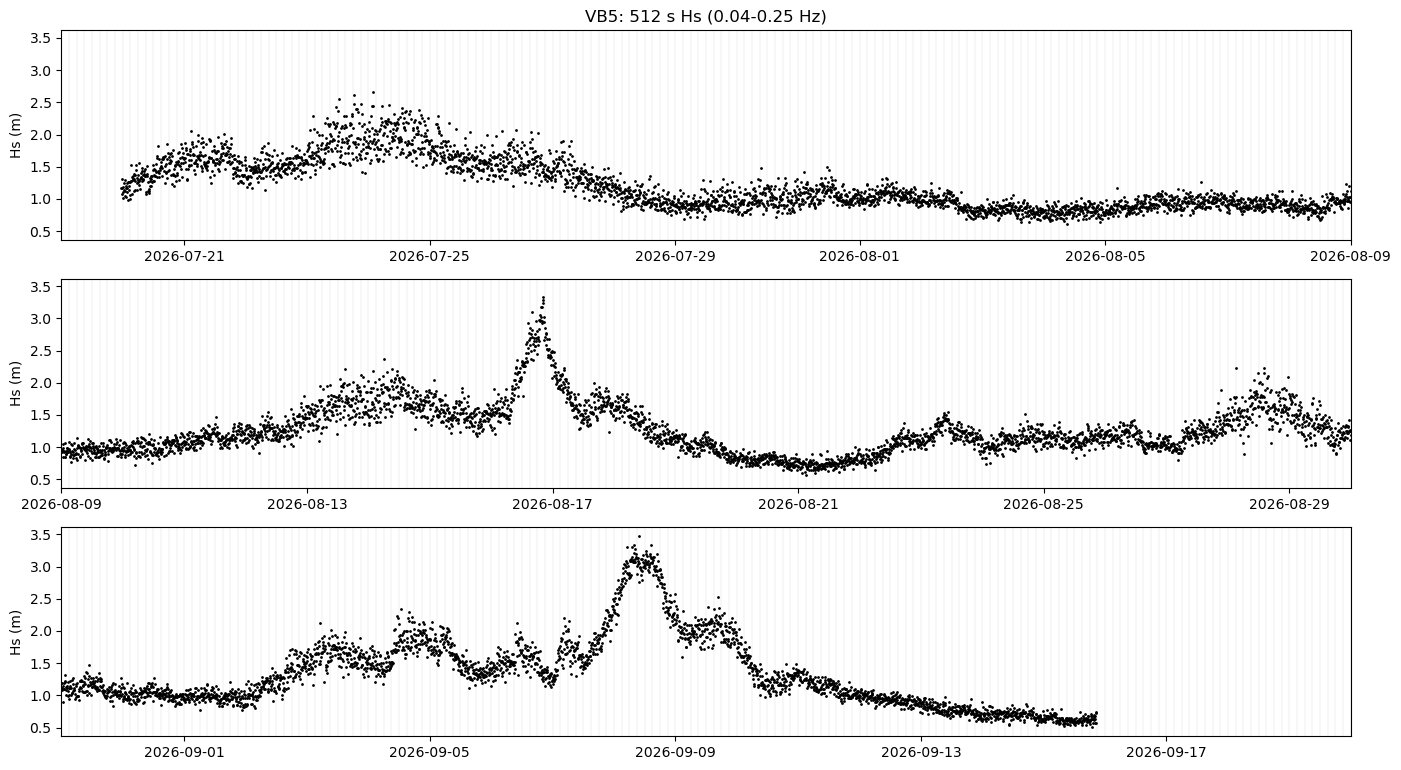

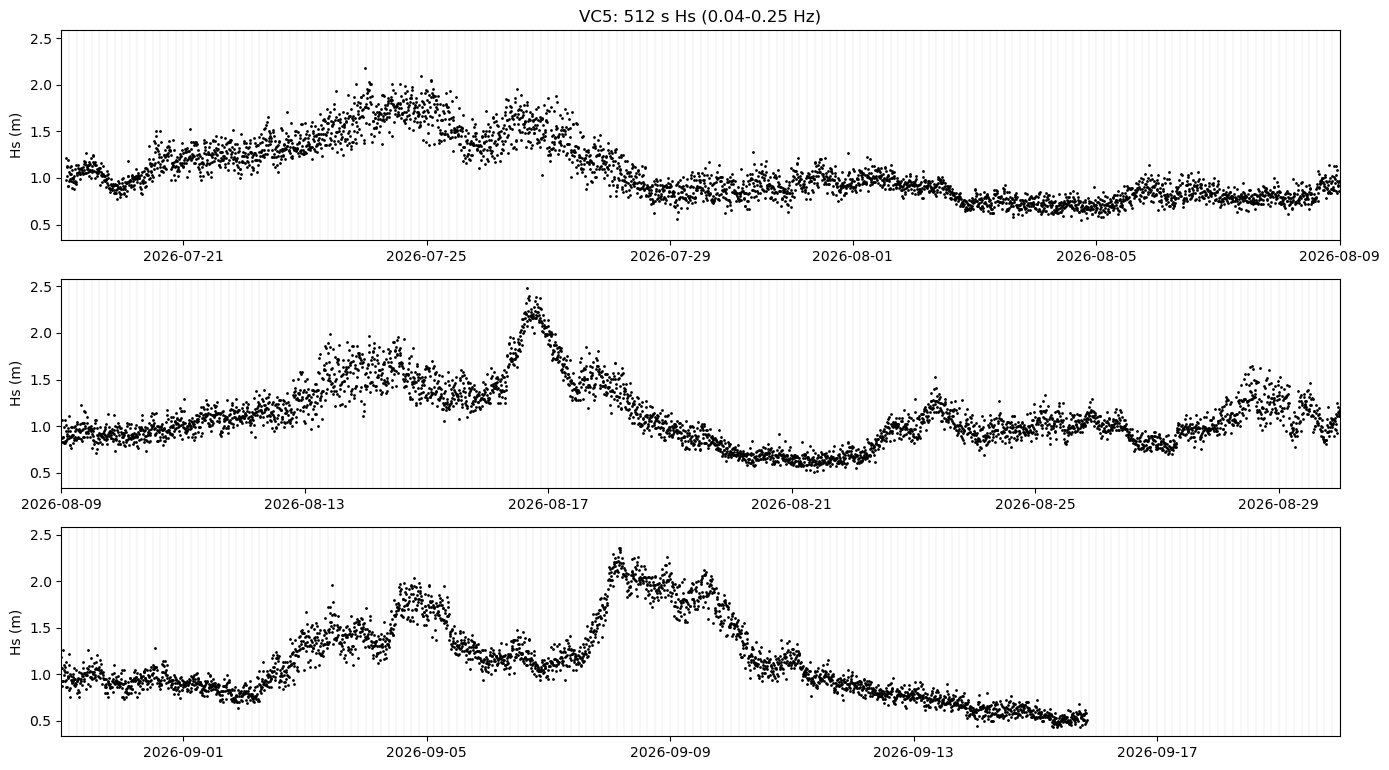

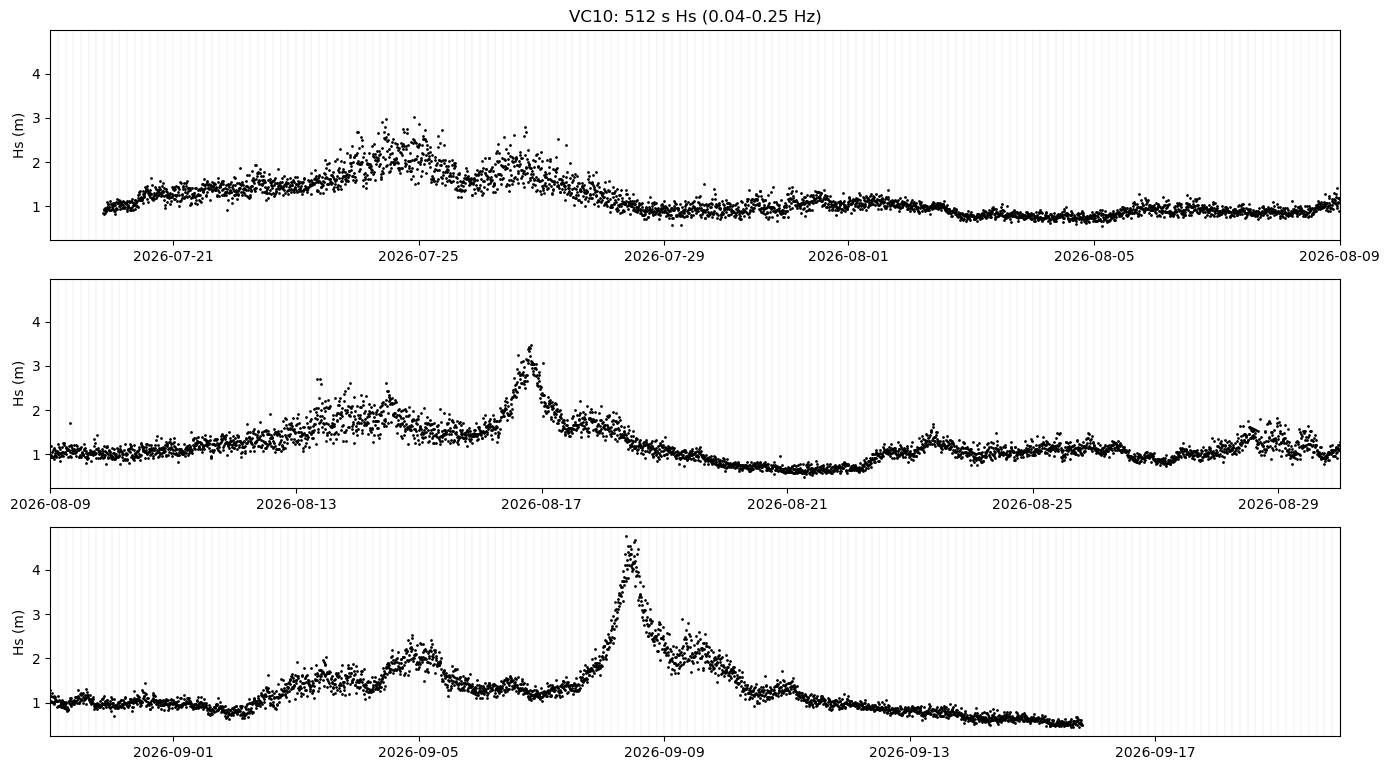

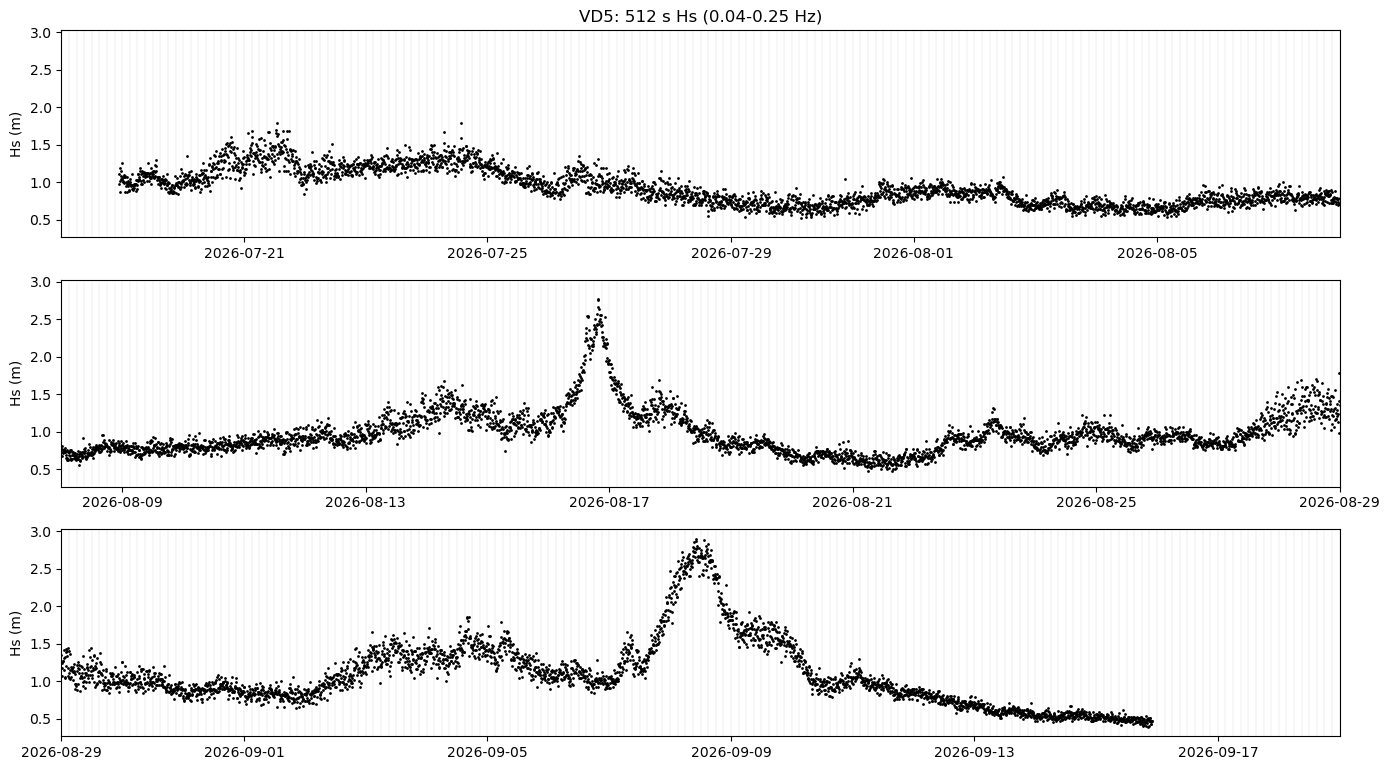

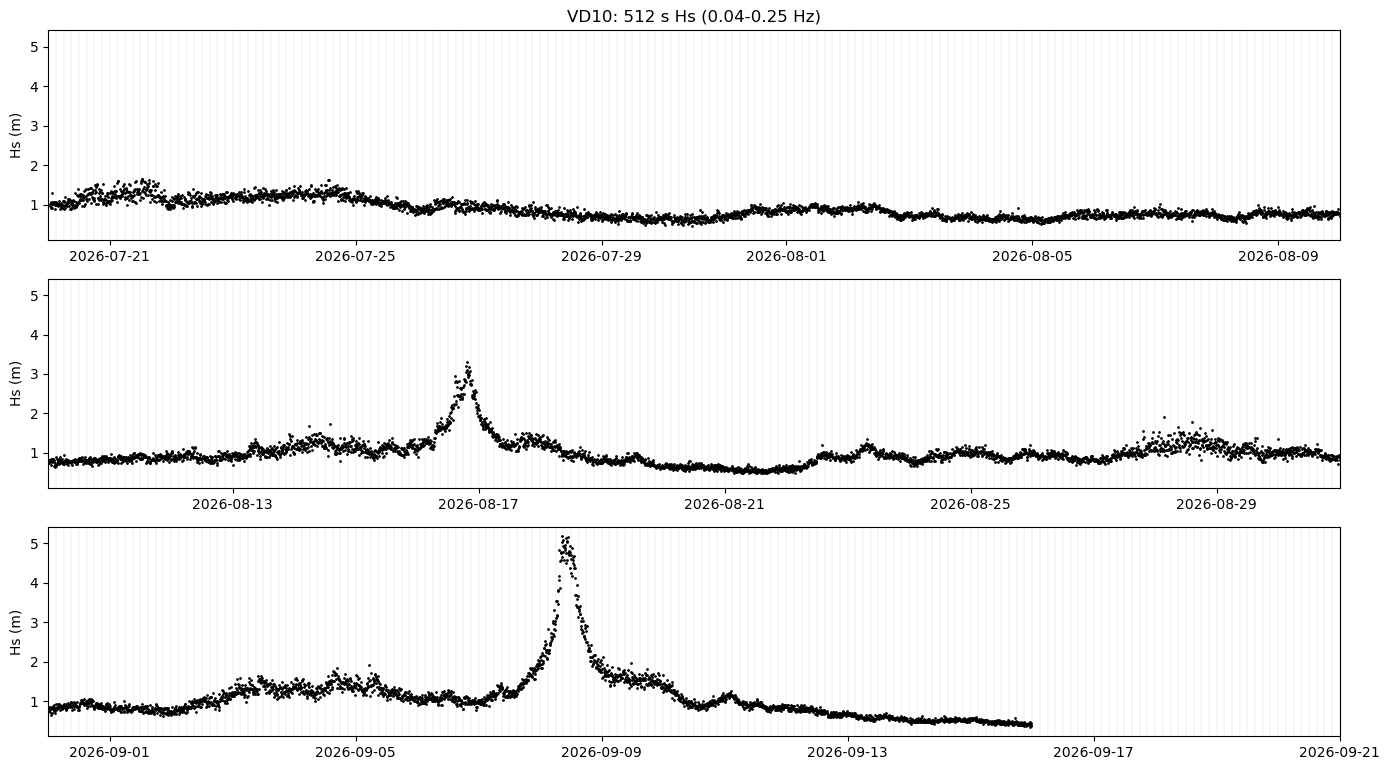

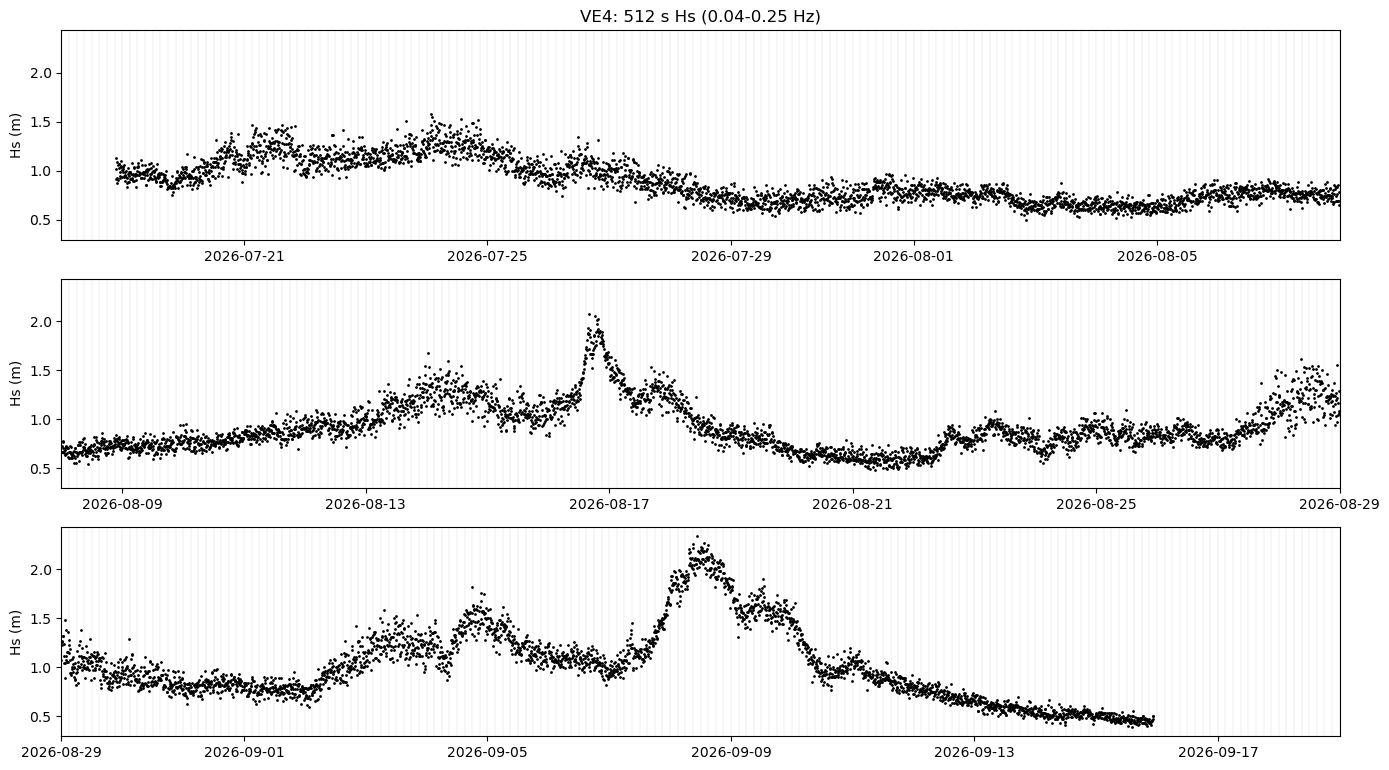

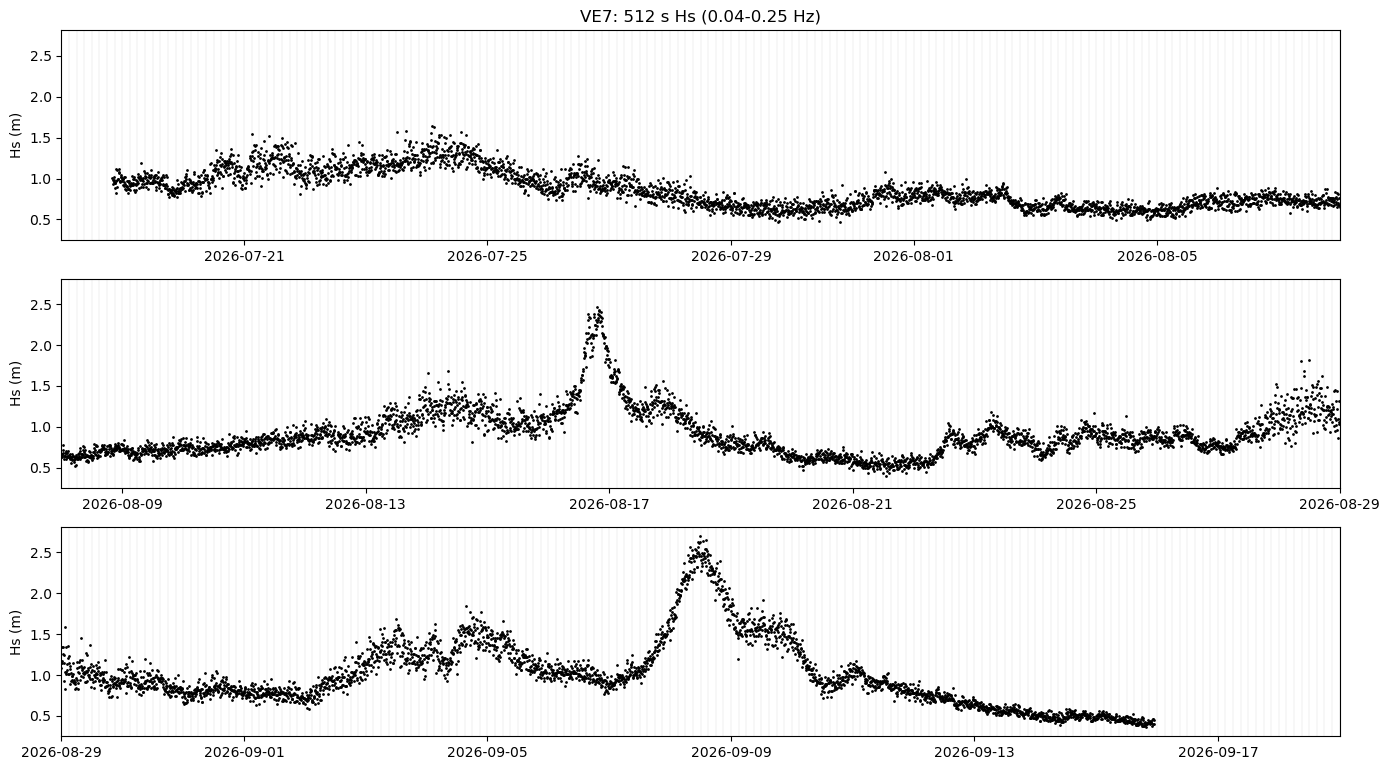

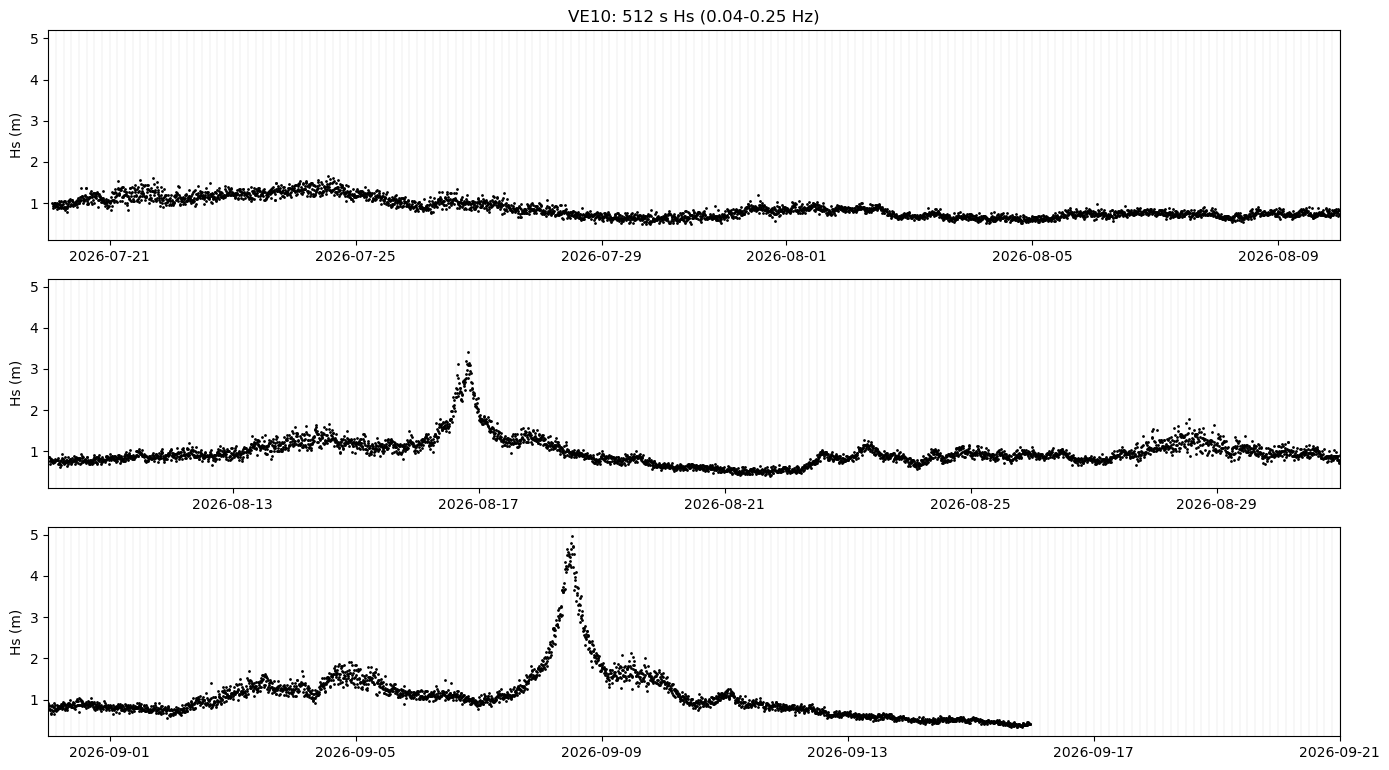

In [6]:
for S in SENSORS:
    plot_hs(hs[S], S)